In [1]:

# 1. MOUNT & SETUP


from google.colab import drive
drive.mount('/content/drive')

import os, zipfile


os.makedirs("/content/Recap_Image_Dataset/original", exist_ok=True)
os.makedirs("/content/Recap_Image_Dataset/photo_of_photo", exist_ok=True)

# Unzip
with zipfile.ZipFile("/content/drive/MyDrive/Recap_Image_Dataset/original.zip", 'r') as zip_ref:
     zip_ref.extractall("/content/Recap_Image_Dataset/original")

with zipfile.ZipFile("/content/drive/MyDrive/Recap_Image_Dataset/photo_of_photo.zip", 'r') as zip_ref:
     zip_ref.extractall("/content/Recap_Image_Dataset/photo_of_photo")


print(os.listdir("/content/Recap_Image_Dataset"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['photo_of_photo', 'original']


In [2]:

# 2. IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, random_split, WeightedRandomSampler
from PIL import Image
from tqdm import tqdm
import numpy as np

In [3]:

# 3. TRANSFORMS

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:

# 4. DATASET
def is_valid_image(path):
    try:
        img = Image.open(path); img.verify(); return True
    except: return False


full_dataset = ImageFolder(
    "/content/Recap_Image_Dataset",
    transform=train_tf,
    is_valid_file=is_valid_image
)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

targets = torch.tensor(full_dataset.targets)
class_counts = torch.bincount(targets)
print("Class counts:", class_counts)


n = len(full_dataset)
indices = torch.randperm(n, generator=torch.Generator().manual_seed(42)).tolist()

n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val:]


import copy

train_dataset = Subset(full_dataset, train_idx)

val_dataset_base  = copy.copy(full_dataset)
val_dataset_base.transform = eval_tf
val_dataset = Subset(val_dataset_base, val_idx)

test_dataset_base = copy.copy(full_dataset)
test_dataset_base.transform = eval_tf
test_dataset = Subset(test_dataset_base, test_idx)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['original', 'photo_of_photo']
Total images: 11242
Class counts: tensor([10784,   458])
Train: 7869 | Val: 1686 | Test: 1687


In [5]:

# 5. WEIGHTED SAMPLER

train_targets = [full_dataset.targets[i] for i in train_idx]
class_sample_counts = torch.bincount(torch.tensor(train_targets))
print("Train class counts:", class_sample_counts)

# Weight per sample = 1 / class_frequency
weights_per_class = 1.0 / class_sample_counts.float()
sample_weights    = torch.tensor([weights_per_class[t] for t in train_targets])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Train class counts: tensor([7544,  325])


In [6]:

# 6. DATALOADERS

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

In [7]:

# 7. MODEL — Resnet50 pretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 1)
)
model = model.to(device)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [8]:

# 8. LOSS
train_class_counts = class_sample_counts.float()
pos_weight = (train_class_counts[0] / train_class_counts[1]).to(device)
print(f"pos_weight: {pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

pos_weight: 23.21


In [9]:

# 9. OPTIMIZER

optimizer = optim.AdamW([
    {"params": list(model.layer1.parameters()) +
               list(model.layer2.parameters()), "lr": 5e-6},
    {"params": list(model.layer3.parameters()) +
               list(model.layer4.parameters()), "lr": 1e-5},
    {"params": model.fc.parameters(),           "lr": 1e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

In [17]:

# 10. TRAINING LOOP

from sklearn.metrics import f1_score, classification_report

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(training):
        for images, labels in tqdm(loader, desc="Train" if training else "Eval", leave=False):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            probs  = torch.sigmoid(outputs)
            preds  = (probs > 0.5).float()
            correct += (preds.squeeze() == labels.squeeze()).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.squeeze().cpu().int().tolist())
            all_labels.extend(labels.squeeze().cpu().int().tolist())

    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / total, correct / total, f1

history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss":   [], "val_acc":   [], "val_f1":   []
}


EPOCHS       = 15
best_val_f1  = 0.0
patience     = 4
no_improve   = 0
best_path    = "/content/best_model.pth"

for ep in range(EPOCHS):
    print(f"\n── Epoch {ep+1}/{EPOCHS} ──────────────────────")

    train_loss, train_acc, train_f1 = run_epoch(train_loader, training=True)
    val_loss,   val_acc,   val_f1   = run_epoch(val_loader,   training=False)
    scheduler.step()

    print(f"Train  loss={train_loss:.4f}  acc={train_acc:.4f}  F1={train_f1:.4f}")
    print(f"Val    loss={val_loss:.4f}  acc={val_acc:.4f}  F1={val_f1:.4f}")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_path)
        print(f"  ✓ New best model saved (val F1={best_val_f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print("Early stopping triggered.")
            break


model.load_state_dict(torch.load(best_path))
print("\nBest model loaded.")


── Epoch 1/15 ──────────────────────


Train  loss=0.1491  acc=0.9719  F1=0.9723
Val    loss=0.1903  acc=0.9709  F1=0.7263
  ✓ New best model saved (val F1=0.7263)

── Epoch 2/15 ──────────────────────


Train  loss=0.1275  acc=0.9790  F1=0.9798
Val    loss=0.1992  acc=0.9662  F1=0.6952
  No improvement (1/4)

── Epoch 3/15 ──────────────────────


Train  loss=0.1405  acc=0.9712  F1=0.9718
Val    loss=0.1914  acc=0.9680  F1=0.7065
  No improvement (2/4)

── Epoch 4/15 ──────────────────────


Train  loss=0.1345  acc=0.9755  F1=0.9760
Val    loss=0.1486  acc=0.9792  F1=0.7879
  ✓ New best model saved (val F1=0.7879)

── Epoch 5/15 ──────────────────────


...

Train  loss=0.0880  acc=0.9849  F1=0.9849
Val    loss=0.1231  acc=0.9804  F1=0.7975
  No improvement (1/4)

── Epoch 12/15 ──────────────────────


Train  loss=0.0769  acc=0.9856  F1=0.9859
Val    loss=0.0882  acc=0.9875  F1=0.8609
  ✓ New best model saved (val F1=0.8609)

── Epoch 13/15 ──────────────────────


Train  loss=0.0751  acc=0.9839  F1=0.9841
Val    loss=0.0807  acc=0.9864  F1=0.8497
  No improvement (1/4)

── Epoch 14/15 ──────────────────────


Train  loss=0.0726  acc=0.9868  F1=0.9869
Val    loss=0.0788  acc=0.9870  F1=0.8553
  No improvement (2/4)

── Epoch 15/15 ──────────────────────


Train  loss=0.0553  acc=0.9893  F1=0.9894
Val    loss=0.0636  acc=0.9893  F1=0.8784
  ✓ New best model saved (val F1=0.8784)

Best model loaded.


In [18]:

# 11. TEST EVALUATION
from sklearn.metrics import classification_report

def collect_preds(loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Test", leave=False):
            images = images.to(device)
            outputs = torch.sigmoid(model(images))
            preds   = (outputs > 0.5).float().squeeze().cpu()
            all_preds.extend(preds.int().tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(outputs.squeeze().cpu().tolist())
    return all_labels, all_preds, all_probs

y_true, y_pred, y_prob = collect_preds(test_loader)
print(classification_report(y_true, y_pred,
      target_names=full_dataset.classes))

                precision    recall  f1-score   support

      original       1.00      0.99      1.00      1619
photo_of_photo       0.87      0.97      0.92        68

      accuracy                           0.99      1687
     macro avg       0.93      0.98      0.96      1687
  weighted avg       0.99      0.99      0.99      1687



Prediction: photo_of_photo
Confidence: 0.9999


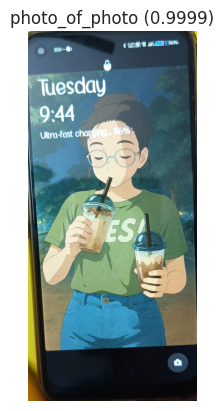

In [19]:

def predict_image(image_path, threshold=0.5):
    img = Image.open(image_path).convert("RGB")
    tensor = eval_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()
    label = full_dataset.classes[int(prob > threshold)]
    return label, prob

# ──test
import random, matplotlib.pyplot as plt

test_folder = "/content/drive/MyDrive/test_data"
valid_ext   = (".jpg", ".jpeg", ".png")
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(valid_ext)]
image_path  = os.path.join(test_folder, random.choice(image_files))

label, prob = predict_image(image_path)
print("Prediction:", label)
print("Confidence:", f"{prob:.4f}")

img = Image.open(image_path)
plt.imshow(img); plt.title(f"{label} ({prob:.4f})"); plt.axis("off"); plt.show()

Evaluating: 100%|██████████| 27/27 [00:11<00:00,  2.40it/s]


                precision    recall  f1-score   support

      original     0.9988    0.9938    0.9963      1619
photo_of_photo     0.8684    0.9706    0.9167        68

      accuracy                         0.9929      1687
     macro avg     0.9336    0.9822    0.9565      1687
  weighted avg     0.9935    0.9929    0.9931      1687



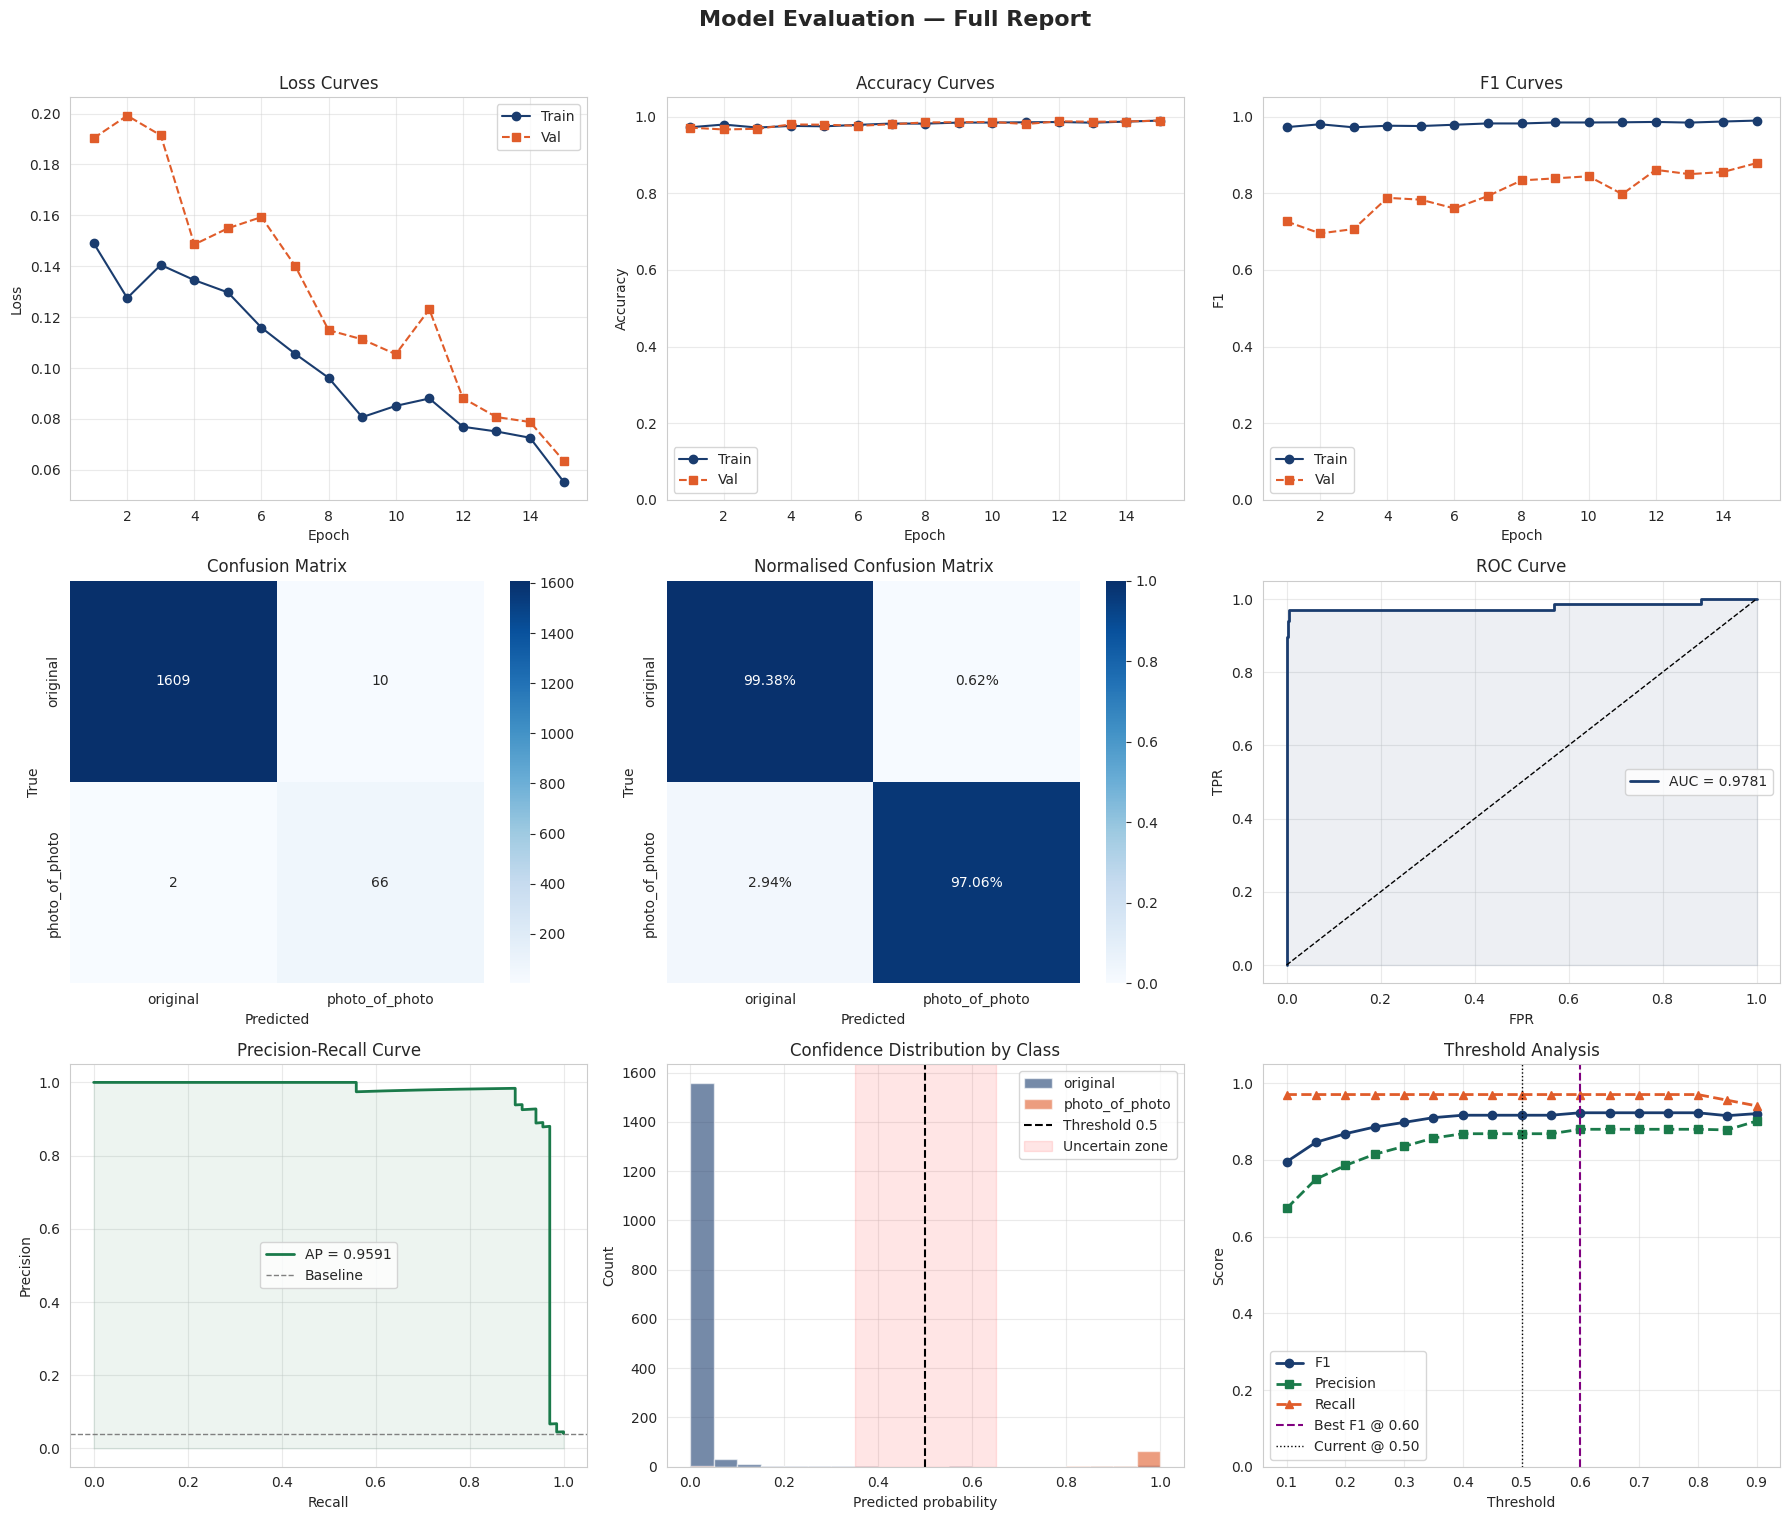


TN=1609 | FP=10 | FN=2 | TP=66
ROC AUC: 0.9781 | Avg Precision: 0.9591
Best threshold for F1: 0.60 → F1 = 0.9231
Saved → /content/drive/MyDrive/model_evaluation/full_evaluation.png


In [ ]:

# EVALUATION

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score,
    precision_score, recall_score
)

SAVE_PATH   = "/content/drive/MyDrive/model_evaluation/"
CLASS_NAMES = full_dataset.classes
os.makedirs(SAVE_PATH, exist_ok=True)
sns.set_style("whitegrid")

# ── Collect predictions ───────────────────────────────────────────────
model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images  = images.to(device)
        probs   = torch.sigmoid(model(images)).squeeze().cpu()
        preds   = (probs > 0.5).int()
        if probs.dim() == 0:
            probs = probs.unsqueeze(0)
            preds = preds.unsqueeze(0)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# ── Classification report ─────────────────────────────────────────────
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ── Metrics ───────────────────────────────────────────────────────────
cm              = confusion_matrix(y_true, y_pred)
cm_norm         = cm.astype(float) / cm.sum(axis=1, keepdims=True)
tn, fp, fn, tp  = cm.ravel()
fpr, tpr, _     = roc_curve(y_true, y_prob)
roc_auc         = auc(fpr, tpr)
precision_c, recall_c, _ = precision_recall_curve(y_true, y_prob)
avg_precision   = average_precision_score(y_true, y_prob)
epochs_ran      = len(history["train_loss"])
epoch_range     = range(1, epochs_ran + 1)

# Threshold sweep
thresholds  = np.arange(0.1, 0.91, 0.05)
f1s         = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in thresholds]
precs       = [precision_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in thresholds]
recs        = [recall_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in thresholds]
best_t      = thresholds[np.argmax(f1s)]

# ── All plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Model Evaluation — Full Report", fontsize=16, fontweight="bold", y=1.01)

# 1 — Loss
ax = axes[0, 0]
ax.plot(epoch_range, history["train_loss"], "o-", label="Train", color="#1a3c6e")
ax.plot(epoch_range, history["val_loss"],   "s--", label="Val",  color="#e05c2a")
ax.set_title("Loss Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.4)

# 2 — Accuracy
ax = axes[0, 1]
ax.plot(epoch_range, history["train_acc"], "o-", label="Train", color="#1a3c6e")
ax.plot(epoch_range, history["val_acc"],   "s--", label="Val",  color="#e05c2a")
ax.set_title("Accuracy Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.4)

# 3 — F1
ax = axes[0, 2]
ax.plot(epoch_range, history["train_f1"], "o-", label="Train", color="#1a3c6e")
ax.plot(epoch_range, history["val_f1"],   "s--", label="Val",  color="#e05c2a")
ax.set_title("F1 Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.4)

# 4 — Confusion matrix
ax = axes[1, 0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# 5 — Normalised confusion matrix
ax = axes[1, 1]
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1, ax=ax)
ax.set_title("Normalised Confusion Matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# 6 — ROC curve
ax = axes[1, 2]
ax.plot(fpr, tpr, color="#1a3c6e", linewidth=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0,1],[0,1], "k--", linewidth=1)
ax.fill_between(fpr, tpr, alpha=0.08, color="#1a3c6e")
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(); ax.grid(alpha=0.4)

# 7 — Precision-Recall
ax = axes[2, 0]
ax.plot(recall_c, precision_c, color="#1a7a4a", linewidth=2, label=f"AP = {avg_precision:.4f}")
ax.axhline(y_true.sum()/len(y_true), color="gray", linestyle="--", linewidth=1, label="Baseline")
ax.fill_between(recall_c, precision_c, alpha=0.08, color="#1a7a4a")
ax.set_title("Precision-Recall Curve"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(alpha=0.4)

# 8 — Confidence distribution
ax = axes[2, 1]
for cls_idx, cls_name, color in zip([0,1], CLASS_NAMES, ["#1a3c6e","#e05c2a"]):
    ax.hist(y_prob[y_true == cls_idx], bins=20, alpha=0.6, label=cls_name, color=color)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold 0.5")
ax.axvspan(0.35, 0.65, alpha=0.1, color="red", label="Uncertain zone")
ax.set_title("Confidence Distribution by Class")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Count")
ax.legend(); ax.grid(alpha=0.4)

# 9 — Threshold analysis
ax = axes[2, 2]
ax.plot(thresholds, f1s,   "o-",  label="F1",        color="#1a3c6e", linewidth=2)
ax.plot(thresholds, precs, "s--", label="Precision",  color="#1a7a4a", linewidth=2)
ax.plot(thresholds, recs,  "^--", label="Recall",     color="#e05c2a", linewidth=2)
ax.axvline(best_t, color="purple", linestyle="--", linewidth=1.5, label=f"Best F1 @ {best_t:.2f}")
ax.axvline(0.5,    color="black",  linestyle=":",  linewidth=1,   label="Current @ 0.50")
ax.set_title("Threshold Analysis"); ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}full_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────
print(f"\nTN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"ROC AUC: {roc_auc:.4f} | Avg Precision: {avg_precision:.4f}")
print(f"Best threshold for F1: {best_t:.2f} → F1 = {max(f1s):.4f}")
print(f"Saved → {SAVE_PATH}full_evaluation.png")

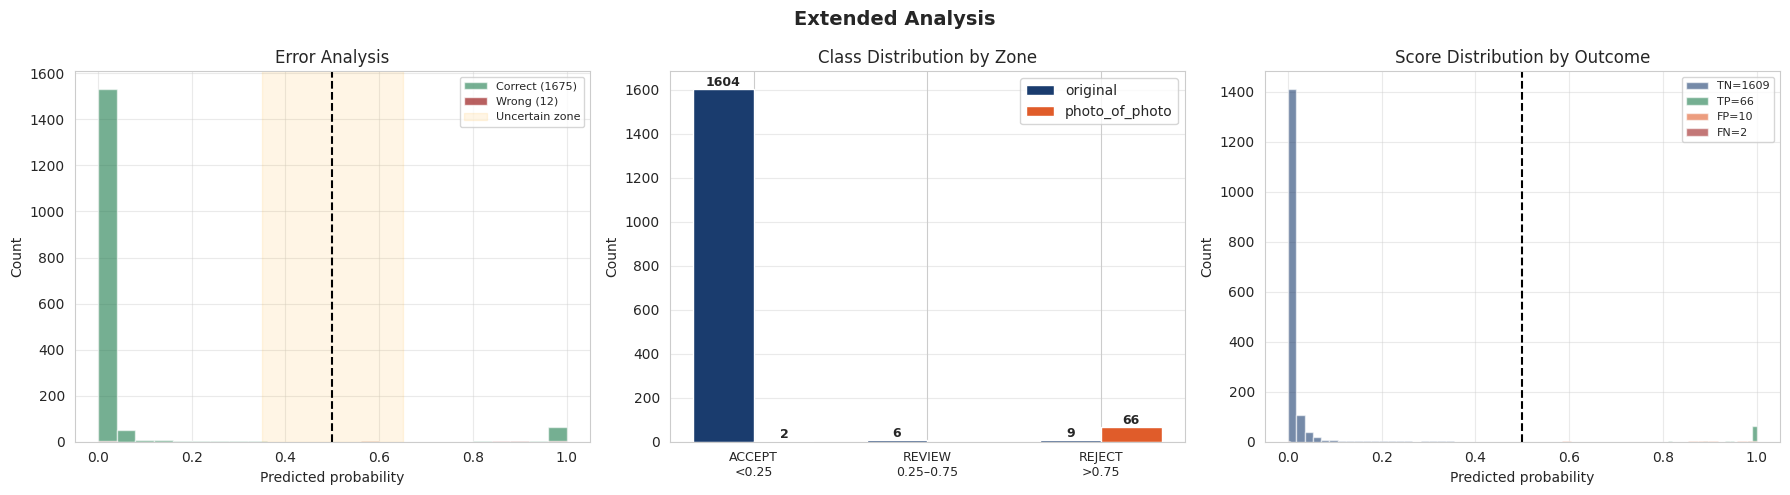

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Extended Analysis", fontsize=14, fontweight="bold")

CLASS_NAMES = full_dataset.classes
x, width    = np.arange(3), 0.35
zone_masks  = [y_prob < 0.25, (y_prob >= 0.25) & (y_prob <= 0.75), y_prob > 0.75]
zone_labels = ["ACCEPT\n<0.25", "REVIEW\n0.25–0.75", "REJECT\n>0.75"]
correct     = y_true == y_pred

# 1 — Error analysis
axes[0].hist(y_prob[correct],  bins=25, alpha=0.6, color="#1a7a4a", edgecolor="white", label=f"Correct ({correct.sum()})")
axes[0].hist(y_prob[~correct], bins=25, alpha=0.7, color="#9b1c1c", edgecolor="white", label=f"Wrong ({(~correct).sum()})")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.5)
axes[0].axvspan(0.35, 0.65, alpha=0.1, color="orange", label="Uncertain zone")
axes[0].set(title="Error Analysis", xlabel="Predicted probability", ylabel="Count")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.4)

# 2 — Class by decision zone
for i, (cls, name, color) in enumerate(zip([0,1], CLASS_NAMES, ["#1a3c6e","#e05c2a"])):
    counts = [((y_true == cls) & m).sum() for m in zone_masks]
    bars   = axes[1].bar(x + i*width, counts, width, label=name, color=color, edgecolor="white")
    [axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, str(int(b.get_height())),
                  ha="center", va="bottom", fontsize=9, fontweight="bold") for b in bars if b.get_height() > 0]
axes[1].set(title="Class Distribution by Zone", ylabel="Count")
axes[1].set_xticks(x + width/2); axes[1].set_xticklabels(zone_labels, fontsize=9)
axes[1].legend(); axes[1].grid(alpha=0.4, axis="y")

# 3 — Score distribution by outcome
groups = {
    f"TN={((y_true==0)&(y_pred==0)).sum()}": (y_prob[(y_true==0)&(y_pred==0)], "#1a3c6e"),
    f"TP={((y_true==1)&(y_pred==1)).sum()}": (y_prob[(y_true==1)&(y_pred==1)], "#1a7a4a"),
    f"FP={((y_true==0)&(y_pred==1)).sum()}": (y_prob[(y_true==0)&(y_pred==1)], "#e05c2a"),
    f"FN={((y_true==1)&(y_pred==0)).sum()}": (y_prob[(y_true==1)&(y_pred==0)], "#9b1c1c"),
}
[axes[2].hist(p, bins=20, alpha=0.6, color=c, edgecolor="white", label=l)
 for l, (p, c) in groups.items() if len(p) > 0]
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1.5)
axes[2].set(title="Score Distribution by Outcome", xlabel="Predicted probability", ylabel="Count")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}extended_analysis.png", dpi=150, bbox_inches="tight")
plt.show()